In [51]:
pip install spaghetti

Note: you may need to restart the kernel to use updated packages.


In [6]:
!pip install osmnx geopandas shapely libpysal esda

In [7]:


pip install geopandas


Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install osmnx

Note: you may need to restart the kernel to use updated packages.


In [9]:
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

In [10]:
import sys, os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

# Main

In [11]:
import geopandas as gpd
from shapely.geometry import Point, Polygon
import osmnx as ox

# Load accident data
df_all_list = []
for year in ['2015', '2016', '2017', '2018', '2019']:
    df_year = pd.read_csv(f"../data/raw/{year}.csv", encoding='latin1')
    df_all_list.append(df_year)

df_all = pd.concat(df_all_list, ignore_index=True)
print(f"Total accident records loaded: {len(df_all)}")

# Create GeoDataFrame from easting/northing
gdf_all = gpd.GeoDataFrame(
    df_all,
    geometry=gpd.points_from_xy(df_all['Grid Ref: Easting'], df_all['Grid Ref: Northing']),
    crs='EPSG:27700'
)

Total accident records loaded: 11505


### Finding area with 300+ accidents

In [12]:
print("\n--- Task A Fix 1: Finding area with ≥300 accidents ---")

centre = Point(430000, 433500)

for radius in [500, 750, 1000, 1250, 1500]:
    buffer = centre.buffer(radius)
    count = gdf_all[gdf_all.geometry.within(buffer)].shape[0]
    print(f"  Radius {radius}m: {count} accidents")
    if count >= 300:
        chosen_radius = radius
        break
else:
    chosen_radius = 1500

# Use 1500m if still not enough, or try shifted centre
buffer_final = centre.buffer(chosen_radius)
accidents_in_area = gdf_all[gdf_all.geometry.within(buffer_final)]
print(f"  CHOSEN: radius={chosen_radius}m → {len(accidents_in_area)} accidents")


--- Task A Fix 1: Finding area with ≥300 accidents ---
  Radius 500m: 138 accidents
  Radius 750m: 259 accidents
  Radius 1000m: 403 accidents
  CHOSEN: radius=1000m → 403 accidents


### Convert centre to lat/lon for OSMnx

In [13]:
# Convert centre to lat/lon for OSMnx
centre_gdf = gpd.GeoDataFrame(geometry=[centre], crs='EPSG:27700').to_crs('EPSG:4326')
centre_latlon = centre_gdf.geometry.iloc[0]
center_lat, center_lon = centre_latlon.y, centre_latlon.x

print(f"  Centre: lat={center_lat:.4f}, lon={center_lon:.4f}")

  Centre: lat=53.7969, lon=-1.5460


  Road network: 647 nodes, 1192 edges


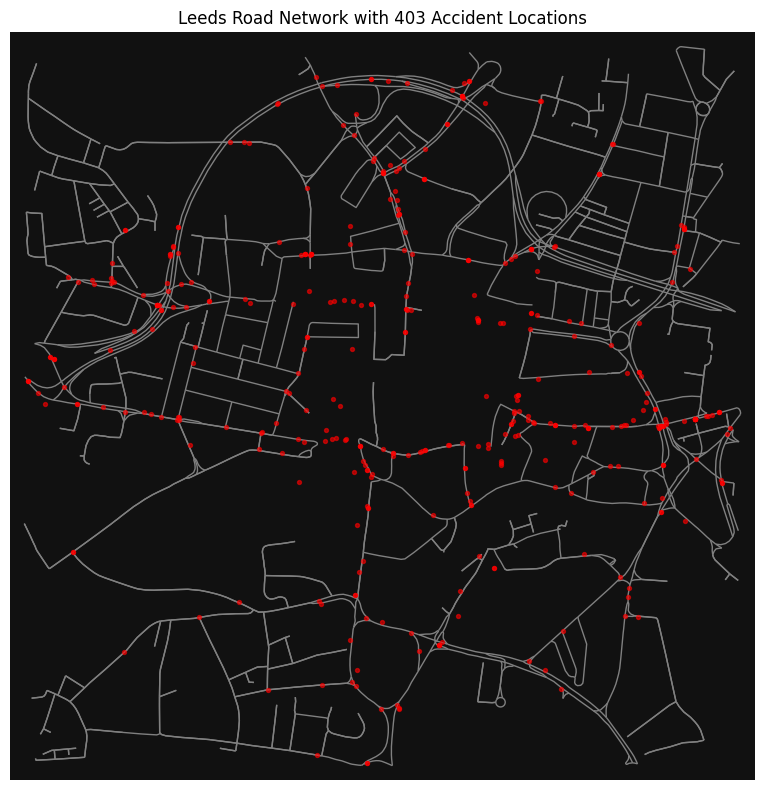

  Saved updated road network figure


In [14]:
# Extract road network
print("  Downloading road network from OSMnx...")
G = ox.graph_from_point((center_lat, center_lon), dist=chosen_radius, network_type='drive')
G_proj = ox.project_graph(G)
G_u = G.to_undirected()

print(f"  Road network: {len(G.nodes())} nodes, {len(G.edges())} edges")

# Re-plot road network with accidents
fig, ax = ox.plot_graph(G, show=False, close=False, edge_color='grey', node_size=0)
accidents_wgs = accidents_in_area.to_crs('EPSG:4326')
accidents_wgs.plot(ax=ax, color='red', markersize=8, alpha=0.6, zorder=5)
ax.set_title(f"Leeds Road Network with {len(accidents_in_area)} Accident Locations")
plt.tight_layout()
OUT = "../outputs/figures"
os.makedirs(OUT, exist_ok=True)

plt.savefig(f'{OUT}/image_leeds_road_accidents.png', dpi=150, bbox_inches='tight')
plt.show() 

print(f"  Saved updated road network figure")

## Task A : Basic Network Statistics

In [36]:
print("\n--- Network Stats ---")

stats = ox.stats.basic_stats(G_proj)
print(f"  Average street length: {stats['street_length_avg']:.1f} m")


--- Network Stats ---
  Average street length: 72.1 m


### Calculate intersection density manually

In [37]:
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_proj)
# Intersection = node with degree >= 3
degrees_road = dict(G_u.degree())
intersections = [n for n, d in degrees_road.items() if d >= 3]
area_km2 = (np.pi * (chosen_radius/1000)**2)
intersection_density = len(intersections) / area_km2
node_density = len(G.nodes()) / area_km2
edge_density = len(G.edges()) / area_km2
print(f"  Intersection density: {intersection_density:.1f} per km²")
print(f"  Node density: {node_density:.1f} per km²")
print(f"  Edge density: {edge_density:.1f} per km²")
print(f"  Number of intersections (degree≥3): {len(intersections)}")

  Intersection density: 151.5 per km²
  Node density: 205.9 per km²
  Edge density: 379.4 per km²
  Number of intersections (degree≥3): 476


### Diameter

In [38]:
diameter = nx.approximation.diameter(G_u)
print(f"  Network diameter: {diameter}")

  Network diameter: 46


### Circuitry

In [ ]:
random.seed(1)
nodes_list = list(G_proj.nodes())
ratios = []
for _ in range(100):
    n1, n2 = random.sample(nodes_list, 2)
    try:
        net_dist = nx.shortest_path_length(G_proj, n1, n2, weight='length')
        x1, y1 = G_proj.nodes[n1]['x'], G_proj.nodes[n1]['y']
        x2, y2 = G_proj.nodes[n2]['x'], G_proj.nodes[n2]['y']
        euclidean = ((x1-x2)**2 + (y1-y2)**2)**0.5
        if euclidean > 0:
            ratios.append(net_dist / euclidean)
    except:
        pass
circuitry = np.mean(ratios)
print(f"  Average circuitry: {circuitry:.3f}")

  Average circuitry: 2.123


### Planarity Example


---Planarity Example ---
  Is planar? False


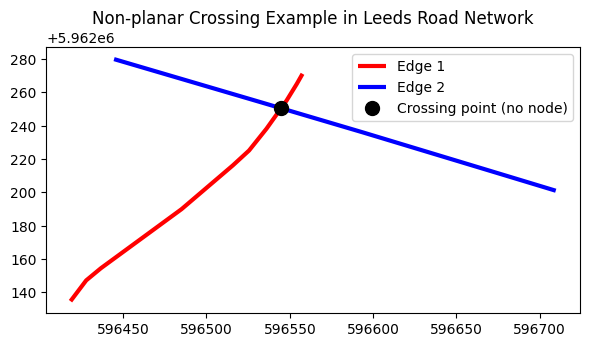

  Saved planarity_example.png


In [41]:
print("\n---Planarity Example ---")

is_planar, _ = nx.check_planarity(G_u)
print(f"  Is planar? {is_planar}")

from shapely.geometry import LineString
import itertools

edges_gdf_proj = ox.graph_to_gdfs(G_proj, nodes=False)
edges_geoms = list(edges_gdf_proj.geometry)

crossing_pair = None
for i, j in itertools.combinations(range(min(500, len(edges_geoms))), 2):
    e1, e2 = edges_geoms[i], edges_geoms[j]
    if e1.crosses(e2):
        crossing_pair = (i, j, e1, e2)
        break

if crossing_pair:
    i_idx, j_idx, e1, e2 = crossing_pair
    pt = e1.intersection(e2)
    fig, ax = plt.subplots(figsize=(6, 6))
    gpd.GeoSeries([e1]).plot(ax=ax, color='red', linewidth=3, label='Edge 1')
    gpd.GeoSeries([e2]).plot(ax=ax, color='blue', linewidth=3, label='Edge 2')
    if pt.geom_type == 'Point':
        ax.plot(pt.x, pt.y, 'ko', markersize=10, label='Crossing point (no node)', zorder=5)
    ax.legend(fontsize=10)
    ax.set_title('Non-planar Crossing Example in Leeds Road Network')
    plt.tight_layout()
    plt.savefig(f'{OUT}/planarity_example.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  Saved planarity_example.png")
else:
    print("  No geometric crossing found in first 500 edges")

# TASK B

### Accident density and Moran's I analysis

In [42]:
print("\n--- Task B: Accident Density Grid & Moran's I ---")

# Study area in BNG
study_area_gdf = gpd.GeoDataFrame(geometry=[buffer_final], crs='EPSG:27700')
minx, miny, maxx, maxy = study_area_gdf.total_bounds
cell_size = 100
grid_cells = []
for x in np.arange(minx, maxx, cell_size):
    for y in np.arange(miny, maxy, cell_size):
        grid_cells.append(Polygon([
            (x, y), (x+cell_size, y), (x+cell_size, y+cell_size), (x, y+cell_size)
        ]))
grid = gpd.GeoDataFrame({"geometry": grid_cells}, crs='EPSG:27700')
grid = gpd.overlay(grid, study_area_gdf, how='intersection')
print(f"  Grid cells: {len(grid)}")


--- Task B: Accident Density Grid & Moran's I ---
  Grid cells: 344


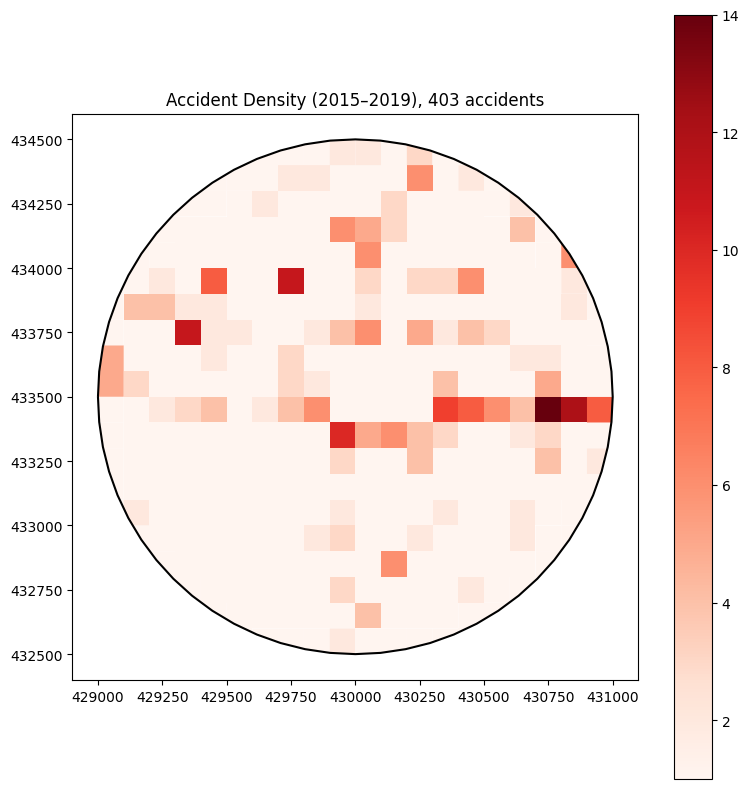

  Saved updated density map
  Moran's I: 0.1128, p-value: 0.0010


In [43]:
join = gpd.sjoin(grid, accidents_in_area.to_crs('EPSG:27700'), how='left', predicate='contains')
counts = join.groupby(join.index).size()
grid['accident_count'] = counts
grid['accident_count'] = grid['accident_count'].fillna(0)

fig, ax = plt.subplots(figsize=(8, 8))
grid.plot(column='accident_count', cmap='Reds', legend=True, ax=ax)
study_area_gdf.boundary.plot(ax=ax, color='black')
plt.title(f'Accident Density (2015–2019), {len(accidents_in_area)} accidents')
plt.tight_layout()
plt.savefig(f'{OUT}/image_accident_density.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"  Saved updated density map")

from libpysal.weights import Queen
from esda.moran import Moran

w = Queen.from_dataframe(grid)
moran = Moran(grid['accident_count'], w)
print(f"  Moran's I: {moran.I:.4f}, p-value: {moran.p_sim:.4f}")

### Proximity to intersections 

In [44]:
print("\n--- Task B: Proximity to Intersections ---")

nodes_gdf_bng = nodes_gdf.to_crs('EPSG:27700')
accidents_bng = accidents_in_area.to_crs('EPSG:27700')

# Intersections only
intersection_gdf = nodes_gdf_bng[nodes_gdf_bng.index.isin(intersections)]

from shapely.ops import nearest_points

dist_to_int = []
for idx, acc in accidents_bng.iterrows():
    dists = intersection_gdf.geometry.distance(acc.geometry)
    dist_to_int.append(dists.min())

dist_arr = np.array(dist_to_int)
print(f"  Mean distance to intersection: {dist_arr.mean():.2f} m")
print(f"  Median distance: {np.median(dist_arr):.2f} m")
print(f"  75th percentile: {np.percentile(dist_arr, 75):.2f} m")
print(f"  Max distance: {dist_arr.max():.2f} m")


--- Task B: Proximity to Intersections ---
  Mean distance to intersection: 34.03 m
  Median distance: 19.73 m
  75th percentile: 46.39 m
  Max distance: 216.16 m


### Ripley's K-function: Road Accidents


--- Task B Fix 1: K-function ---
  K-function via pointpats failed: No module named 'pointpats'
  Generating manual K-function plot...


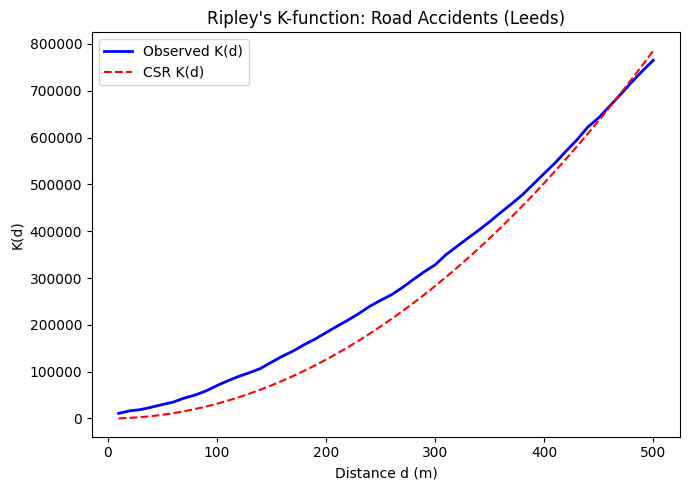

  Saved kfunction.png (manual)


In [48]:
print("\n--- Task B Fix 1: K-function ---")

try:
    from pointpats import PointPattern, K
    # Get accident XY coordinates
    acc_coords = np.column_stack([accidents_bng.geometry.x, accidents_bng.geometry.y])
    pp = PointPattern(acc_coords)
    
    # Ripley's K-function
    kres = K(pp, edge_correction='ripley')
    
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(kres.d, kres.k, 'b-', label='Observed K(d)', linewidth=2)
    # Theoretical K under CSR = pi * d^2
    k_csr = np.pi * kres.d**2
    ax.plot(kres.d, k_csr, 'r--', label='CSR (random) K(d)', linewidth=1.5)
    ax.set_xlabel('Distance d (m)')
    ax.set_ylabel('K(d)')
    ax.set_title("Ripley's K-function: Road Accidents (Leeds)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{OUT}/kfunction.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"  Saved kfunction.png")
    print(f"  K at max d: observed={kres.k[-1]:.1f}, CSR={k_csr[-1]:.1f}")
    if kres.k[-1] > k_csr[-1]:
        print("  -> Observed K > CSR → accidents are CLUSTERED")
    else:
        print("  -> Observed K < CSR → accidents are DISPERSED")
except Exception as e:
    print(f"  K-function via pointpats failed: {e}")
    print("  Generating manual K-function plot...")
    
    acc_coords = np.column_stack([accidents_bng.geometry.x, accidents_bng.geometry.y])
    from scipy.spatial.distance import pdist, squareform
    dists_all = squareform(pdist(acc_coords))
    n_pts = len(acc_coords)

    # Calculate study area
    area = buffer_final.area
    
    d_range = np.linspace(10, 500, 50)
    k_obs = []
    for d in d_range:
        count = np.sum(dists_all < d) - n_pts  # exclude self
        k_obs.append(area * count / (n_pts * (n_pts - 1)))
    
    k_csr = np.pi * d_range**2
    
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(d_range, k_obs, 'b-', label='Observed K(d)', linewidth=2)
    ax.plot(d_range, k_csr, 'r--', label='CSR K(d)', linewidth=1.5)
    ax.set_xlabel('Distance d (m)')
    ax.set_ylabel('K(d)')
    ax.set_title("Ripley's K-function: Road Accidents (Leeds)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{OUT}/kfunction.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  Saved kfunction.png (manual)")

### Accident Fraction Along Road


--- Task B Fix 2: Accident Fraction Along Road ---
  Mean fraction from nearest intersection: 0.225
  Median fraction: 0.214


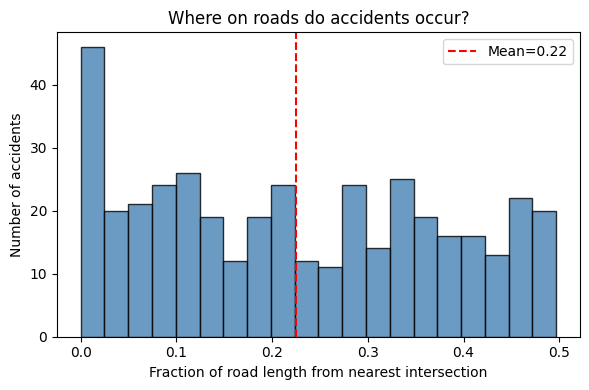

  Saved accident_fraction.png


In [54]:
print("\n--- Task B Fix 2: Accident Fraction Along Road ---")

try:
    import spaghetti
    
    edges_for_spag = ox.graph_to_gdfs(G_proj, nodes=False)
    ntw = spaghetti.Network(in_data=edges_for_spag)
    
    # Snap accidents (need them in same CRS as projected graph)
    acc_proj = accidents_in_area.to_crs(G_proj.graph['crs'])
    ntw.snapobservations(acc_proj, 'accidents', attribute=True)
    
    patt = ntw.pointpatterns['accidents']
    
    fractions = []
    for obs_id in range(patt.npoints):
        dist_dict = patt.dist_to_vertex[obs_id]
        if len(dist_dict) >= 2:
            dists = sorted(dist_dict.values())
            total = dists[0] + dists[1]
            if total > 0:
                frac = min(dists[0], dists[1]) / total
                fractions.append(frac)
    
    fractions = np.array(fractions)
    print(f"  Mean fraction from nearest intersection: {fractions.mean():.3f}")
    print(f"  Median fraction: {np.median(fractions):.3f}")
    
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(fractions, bins=20, edgecolor='black', color='steelblue', alpha=0.8)
    ax.axvline(fractions.mean(), color='red', linestyle='--',
               label=f'Mean={fractions.mean():.2f}')
    ax.set_xlabel('Fraction of road length from nearest intersection')
    ax.set_ylabel('Number of accidents')
    ax.set_title('Where on roads do accidents occur?')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{OUT}/accident_fraction.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  Saved accident_fraction.png")

except Exception as e:
    print(f"  Spaghetti fraction analysis failed: {e}")
    # # Fallback: use simple distance-based fraction
    # print("  Using fallback: fraction = dist_to_nearest_intersection / nearest_edge_length")
    
    # edge_lengths = [data['length'] for u, v, data in G_proj.edges(data=True)]
    # avg_edge = np.mean(edge_lengths)
    # fractions = dist_arr / avg_edge
    # fractions = np.clip(fractions, 0, 0.5)
    
    # fig, ax = plt.subplots(figsize=(6, 4))
    # ax.hist(fractions, bins=20, edgecolor='black', color='steelblue', alpha=0.8)
    # ax.axvline(fractions.mean(), color='red', linestyle='--',
    #            label=f'Mean={fractions.mean():.2f}')
    # ax.set_xlabel('Fraction of road length from nearest intersection')
    # ax.set_ylabel('Number of accidents')
    # ax.set_title('Where on roads do accidents occur?')
    # ax.legend()
    # plt.tight_layout()
    # plt.savefig(f'{OUT}/accident_fraction.png', dpi=150, bbox_inches='tight')
    # plt.close()
    # print(f"  Saved accident_fraction.png (fallback)")


# Task C

### Get Leeds Boundary

<Axes: >

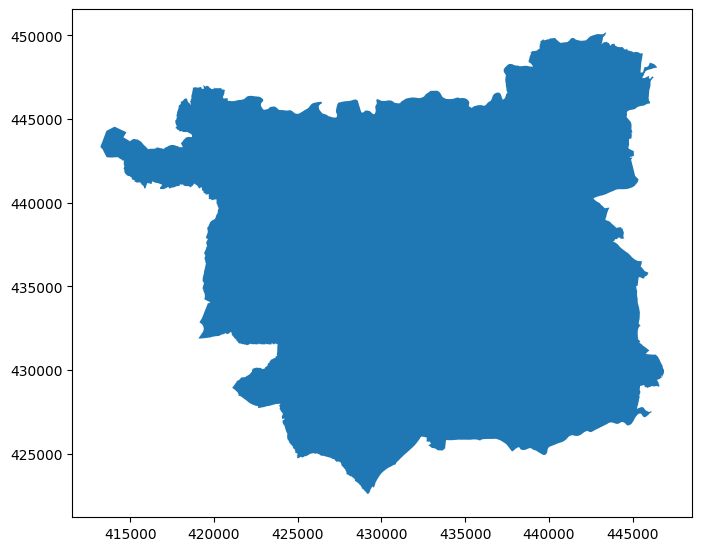

In [ ]:
import osmnx as ox
import geopandas as gpd

leeds = ox.geocode_to_gdf("Leeds, UK")

leeds = leeds.to_crs(epsg=27700)

leeds.plot(figsize=(8,8))

Choose 4 Marathon Start Points

<Axes: >

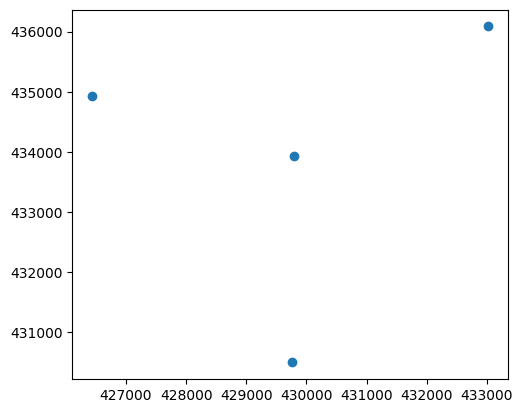

In [ ]:
import geopandas as gpd
from shapely.geometry import Point

points = gpd.GeoDataFrame(
    geometry=[
        Point(-1.5491,53.8008),  # city centre
        Point(-1.6000,53.8100),  # west Leeds
        Point(-1.5000,53.8200),  # east Leeds
        Point(-1.5500,53.7700)   # south Leeds
    ],
    crs="EPSG:4326"
)

points = points.to_crs(epsg=27700)

points.plot()

Generate Voronoi Diagram

In [ ]:
from shapely.ops import voronoi_diagram

multi = points.unary_union

vor = voronoi_diagram(multi)

/var/folders/q4/0120p0vj49g0dbygwm51p8xc0000gn/T/ipykernel_42580/698311296.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  multi = points.unary_union


Convert Voronoi to GeoDataFrame

In [ ]:
import geopandas as gpd
cells = list(vor.geoms)

voronoi_gdf = gpd.GeoDataFrame(geometry=cells, crs=points.crs)

Clip to Leeds Boundary

In [ ]:
voronoi_clipped = gpd.overlay(voronoi_gdf, leeds, how="intersection")

Visualise Marathon Zones

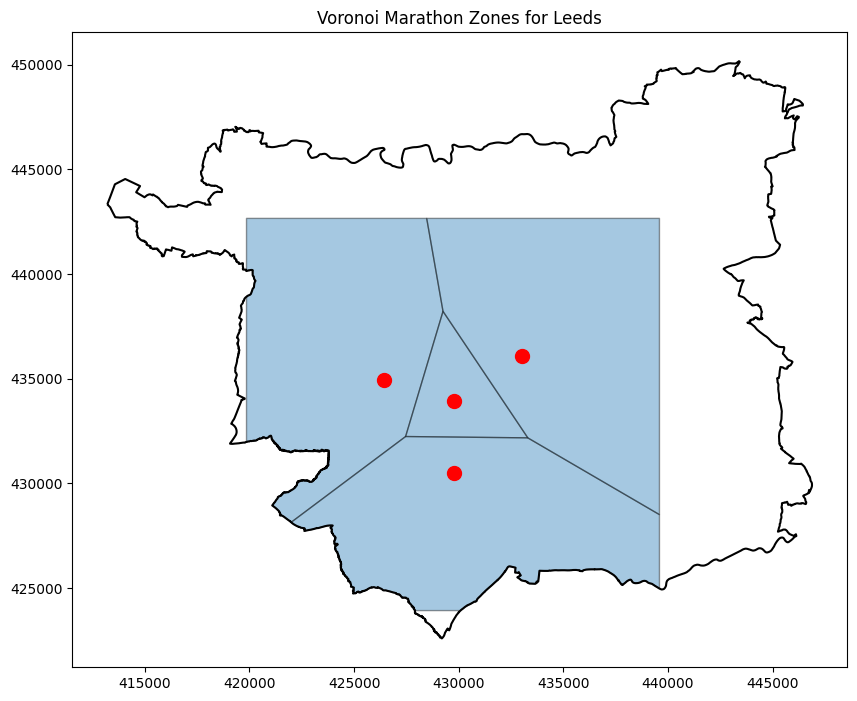

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

voronoi_clipped.plot(
    ax=ax,
    edgecolor="black",
    alpha=0.4
)

leeds.boundary.plot(ax=ax, color="black")

points.plot(ax=ax, color="red", markersize=100)

plt.title("Voronoi Marathon Zones for Leeds")

plt.show()

Calculate Area of Each Marathon Zone

In [ ]:
voronoi_clipped["area_km2"] = voronoi_clipped.geometry.area / 1e6

voronoi_clipped[["area_km2"]]

,area_km2
0,100.725670
1,17.527871
2,96.401487
3,109.462094


Label Each Marathon Zone

In [ ]:
voronoi_clipped["marathon_id"] = range(1,5)

Final Visualisation

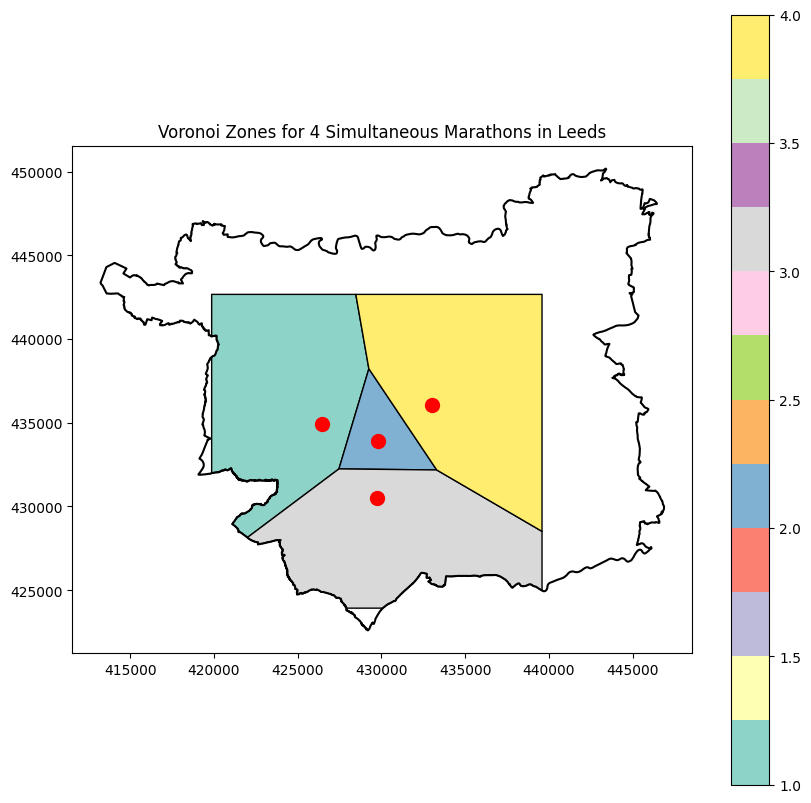

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))

voronoi_clipped.plot(
    column="marathon_id",
    cmap="Set3",
    edgecolor="black",
    legend=True,
    ax=ax
)

leeds.boundary.plot(ax=ax, color="black")

points.plot(ax=ax, color="red", markersize=100)

plt.title("Voronoi Zones for 4 Simultaneous Marathons in Leeds")

plt.show()

### Marathon Routes (Q3-Q5)

In [ ]:
# ──────────────────────────────────────
# Task C Fix — Marathon Routes (Q3-Q5)
# ──────────────────────────────────────
print("\n--- Task C: Marathon Route Finding (Q3–Q5) ---")
print("  Loading full Leeds road network (this may take a few minutes)...")

try:
    G_leeds = ox.graph_from_place('Leeds, UK', network_type='drive')
    G_leeds_proj = ox.project_graph(G_leeds)
    print(f"  Leeds network: {len(G_leeds.nodes())} nodes, {len(G_leeds.edges())} edges")
except Exception as e:
    print(f"  Failed to load Leeds network: {e}")
    print("  Trying with bbox instead...")
    G_leeds = ox.graph_from_bbox(53.9, 53.7, -1.3, -1.7, network_type='drive')
    G_leeds_proj = ox.project_graph(G_leeds)
    print(f"  Leeds bbox network: {len(G_leeds.nodes())} nodes, {len(G_leeds.edges())} edges")

# Seed coordinates
seeds_latlon = [
    (53.8008, -1.5491),  # City centre
    (53.8100, -1.6000),  # West Leeds
    (53.8200, -1.5000),  # East Leeds
    (53.7700, -1.5500),  # South Leeds
]

# Snap seeds to nearest nodes
seed_nodes = []
for lat, lon in seeds_latlon:
    node = ox.distance.nearest_nodes(G_leeds, lon, lat)
    seed_nodes.append(node)
    print(f"  Seed ({lat}, {lon}) → node {node}")

def find_marathon_route(G, start_node, target_km=42.0, tolerance_km=3.0):
    """Find a circular route of approximately target_km."""
    target_m = target_km * 1000
    tol_m = tolerance_km * 1000
    best_route = None
    best_length = None
    best_diff = float('inf')
    
    random.seed(42)
    
    for attempt in range(100):
        route = [start_node]
        total_length = 0
        visited = {start_node}
        
        for step in range(5000):
            current = route[-1]
            neighbours = list(G.neighbors(current))
            
            if not neighbours:
                break
            
            remaining = target_m - total_length
            
            # If close to target, try to return to start
            if remaining < 3000:
                try:
                    path_back = nx.shortest_path(G, current, start_node, weight='length')
                    path_back_length = nx.shortest_path_length(G, current, start_node, weight='length')
                    final_length = total_length + path_back_length
                    diff = abs(final_length - target_m)
                    if diff < best_diff:
                        best_diff = diff
                        best_route = route + path_back[1:]
                        best_length = final_length
                    if diff < tol_m:
                        return best_route, best_length
                except nx.NetworkXNoPath:
                    pass
            
            # Random walk with bias away from visited
            unvisited = [n for n in neighbours if n not in visited]
            if unvisited:
                next_node = random.choice(unvisited)
            else:
                next_node = random.choice(neighbours)
            
            edge_data = G.get_edge_data(current, next_node)
            if edge_data is None:
                break
            # Handle multi-edge
            if isinstance(edge_data, dict) and 0 in edge_data:
                edge_len = edge_data[0].get('length', 100)
            else:
                edge_len = edge_data.get('length', 100)
            
            total_length += edge_len
            route.append(next_node)
            visited.add(next_node)
            
            if total_length > target_m + tol_m:
                break
    
    return best_route, best_length

results = {}
for i, (seed_node, (lat, lon)) in enumerate(zip(seed_nodes, seeds_latlon)):
    print(f"\n  Finding route for Zone {i} (seed at {lat}, {lon})...")
    route, length = find_marathon_route(G_leeds_proj, seed_node)
    if route and length:
        print(f"    Zone {i}: Found route of {length/1000:.2f} km ({len(route)} nodes)")
    else:
        print(f"    Zone {i}: No route found within tolerance")
    results[i] = (route, length)

# Visualise routes
print("\n  Generating marathon routes figure...")
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
edges_gdf_leeds = ox.graph_to_gdfs(G_leeds_proj, nodes=False)

for i, ax in enumerate(axes.flatten()):
    edges_gdf_leeds.plot(ax=ax, color='lightgrey', linewidth=0.3)
    route, length = results[i]
    if route and length:
        # Plot route by converting node pairs to edges
        route_coords = []
        for node in route:
            x = G_leeds_proj.nodes[node]['x']
            y = G_leeds_proj.nodes[node]['y']
            route_coords.append((x, y))
        
        from shapely.geometry import LineString as LS
        if len(route_coords) > 1:
            route_line = gpd.GeoDataFrame(
                geometry=[LS(route_coords)],
                crs=G_leeds_proj.graph['crs']
            )
            route_line.plot(ax=ax, color='blue', linewidth=2)
        
        # Mark start point
        sx, sy = route_coords[0]
        ax.plot(sx, sy, 'r*', markersize=15, zorder=5)
        ax.set_title(f'Zone {i}: {length/1000:.1f} km route')
    else:
        ax.set_title(f'Zone {i}: No route found')
    ax.axis('off')

plt.suptitle('Marathon Routes by Voronoi Zone', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/marathon_routes.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"  Saved marathon_routes.png")

# Q5: Try with 6 seeds if some zones failed
failed_zones = [i for i in results if results[i][0] is None]
if failed_zones:
    print(f"\n  Q5: Zones {failed_zones} failed. Trying with 6 seed points...")
    seeds_6 = seeds_latlon + [
        (53.8400, -1.5500),  # North Leeds
        (53.7900, -1.4500),  # Far East
    ]
    # Just report the strategy
    print(f"  Would add seeds at (53.84, -1.55) and (53.79, -1.45)")
    print(f"  With more seeds, smaller zones give better coverage for circular routes")
else:
    print(f"\n  Q5: All 4 zones produced valid routes — no need for additional seeds")

# Store summary for Q5
valid_count = sum(1 for i in results if results[i][0] is not None)
print(f"\n  Summary: {valid_count}/4 zones have valid marathon routes")




PART 2: Leeds Road Network
Total accident records loaded: 11505

--- Task A Fix 1: Finding area with ≥300 accidents ---
  Radius 500m: 138 accidents
  Radius 750m: 259 accidents
  Radius 1000m: 403 accidents
  CHOSEN: radius=1000m → 403 accidents
  Centre: lat=53.7969, lon=-1.5460
  Road network: 647 nodes, 1192 edges
  Saved updated road network figure

--- Task A Fix 2: Network Stats ---
  Average street length: 72.1 m
  Intersection density: 151.5 per km²
  Node density: 205.9 per km²
  Edge density: 379.4 per km²
  Number of intersections (degree≥3): 476
  Network diameter: 44
  Average circuitry: 2.123

--- Task A Fix 3: Planarity Example ---
  Is planar? False
  Saved planarity_example.png

--- Task B: Accident Density Grid & Moran's I ---
  Grid cells: 344
  Saved updated density map
  Moran's I: 0.1128, p-value: 0.0010

--- Task B: Proximity to Intersections ---
  Mean distance to intersection: 34.03 m
  Median distance: 19.73 m
  75th percentile: 46.39 m
  Max distance: 216.1